In [46]:
import matplotlib_inline
import pandas as pd
import json
from ast import literal_eval
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import re
from datetime import datetime, timedelta
import numpy as np

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Verificação por tempo de uso

1. Limpar o valor de "time"
2. Loop rodando de minuto a minuto verificando o último estado
3. Caso ativado = 1, caso não = 0
4. Cria coluna de hora do dia
5. Agrupa pela hora do dia somando os valores
6. Divide pela quantidade de dias e arredonda para um número inteiro


In [47]:
def remove_message_timestamp(message):
    regex = r"'time': \d+, "
    new_message = re.sub(regex, '', str(message))
    regex = r"'dpId': \d+, "
    new_message = re.sub(regex, '', str(new_message))
    return eval(new_message)

def remove_invalid_codes(message):
    valid_codes = ['switch_led', 'switch_1', 'presence_state']
    result = []
    for state in message:
        if state['code'] in valid_codes:
            result.append(state)
    if len(result) > 0:
        return result
    else:
        return np.nan

def time_interval(dt, minutes=60):
    total_seconds = timedelta(hours=dt.hour, minutes=dt.minute, seconds=dt.second).total_seconds()
    interval = total_seconds // (minutes * 60)
    return int(interval)

def trata_dados_reais(caminho:str):
    message_list = []
    hour_list = []
    with open(caminho, "r") as json:
        data = json.read()
        for line in data.split('\n')[1:-1]:
            hour_list.append(eval(line)['hora'])
            dict_msg = eval(eval(line)['mensagem'].replace('true', 'True').replace('false', 'False'))['bizData']
            message_list.append(dict_msg)
        json.close()

    df = pd.DataFrame(message_list).rename(columns={'properties': 'message'})
    df['timeStamp'] = hour_list
    df['message'] = df['message'].astype(str)

    dicionario = {
        'ebfe6c248a7dfe6910qdcb': 'Plug_fan',
        'eb061b979815289561tyqf': 'Presence_sensor',
        'eb31770a1d7812125degzr': 'Light_bulb',
        'eb176a71685a57c19arlbp': 'Opening_sensor',
        'ebcc9b86347718a3808ezt': 'Plug_pc',
        'ebf1d890916d1a73b4vtnv': 'Humidity_sensor'
    }

    df['devId'] = df['devId'].apply(lambda x: dicionario[x])

    df['message'] = df['message'].apply(remove_message_timestamp)
    df['message'] = df['message'].apply(remove_invalid_codes)
    df['timeStamp'] = df['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%dT%H:%M:%S.%f'))

    df = df[df['message'].notna()].reset_index(drop=True)
    df["day_week"] = df["timeStamp"].dt.day_name()

    unique_devices = ['Presence_sensor', 'Plug_fan', 'Light_bulb', 'Plug_pc']

    for device in unique_devices:
        result = (df[df['devId'] == device]['message'].shift(1) == df[df['devId'] == device]['message']).sum()
        print(f'{device}: {result}')

    remove_index = []
    for device in unique_devices:
        result = df[df['devId'] == device][(df[df['devId'] == device]['message'].shift(1) == df[df['devId'] == device]['message']).values].index.tolist()
        if len(result) > 0:
            remove_index.extend(result)
    df = df.drop(remove_index)
    return df.sort_values('timeStamp', ascending=True).reset_index(drop=True)

def trata_dados_gerados(caminho:str):
    df_gerado = pd.read_csv(caminho)
    colunas = ['devId', 'productKey', 'message', 'timeStamp']

    dicionario = {
        'QUARTO_PLUG_02-004': 'Plug_fan',
        'QUARTO_SENSOR_PRESENCA-002': 'Presence_sensor',
        'QUARTO_LAMPADA-001': 'Light_bulb',
        'QUARTO_PLUG_01-003': 'Plug_pc'
    }

    df_gerado['devId'] = df_gerado['device'].apply(lambda x: dicionario[x])
    df_gerado = df_gerado[colunas]

    df_gerado['timeStamp'] = df_gerado['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%d %H:%M:%S.%f'))
    df_gerado["day_week"] = df_gerado["timeStamp"].dt.day_name()

    return df_gerado.sort_values('timeStamp', ascending=True).reset_index(drop=True)

In [48]:
PATH = './'

real = trata_dados_reais(PATH + 'dados_reais_14_dias.json')
generator = trata_dados_gerados('../dados/original/completo/dados-validacao-temp.csv')

Presence_sensor: 1044
Plug_fan: 0
Light_bulb: 5
Plug_pc: 0


In [49]:
def encoder(data):
    df = data.copy()
    df['message'] = df['message'].astype(str).apply(lambda msg: 0 if msg == None or "'value': 'none'" in msg or "'value': False" in msg or "'value': 'OFF'" in msg
                                            else 1 if "'value': 'presence'" in msg or "'value': True" in msg or "'value': 'ON'" in msg else msg)
    return df.query("message == 0 or message == 1")

In [50]:
real_encoded = encoder(real)
generated_encoded = encoder(generator)

In [51]:
def transform(data, device_id='devId'):
    df = data.copy()
    start = data['timeStamp'].min().replace(minute=0, second=0, microsecond=0)# + timedelta(minutes=1)
    end = data['timeStamp'].max().replace(microsecond=0)
    timestamps = pd.date_range(start=start, end=end, freq='min')
    devices = df[device_id].unique()

    time_on_list = []
    time_on = {device: 0 for device in devices}
    time_on['timeStamp'] = timestamps[0]

    last_state = {device: 0 for device in devices}

    last_timestamp = start - timedelta(minutes=1)
    for i, current_timestamp in enumerate(timestamps):
        for device in devices:
            time = timedelta(seconds=0)
            registers = df[(df['timeStamp'] <= current_timestamp) & (df['timeStamp'] > last_timestamp)].query(f"{device_id} == '{device}'").reset_index(drop=True)

            if len(registers) > 0:
                if len(registers) == 1:
                    if registers.iloc[0]['message'] == 1:
                        time = current_timestamp - registers.iloc[0]['timeStamp']
                    elif last_state[device] == 1 and registers.iloc[0]['message'] == 0:
                        time = registers.iloc[0]['timeStamp'] - last_timestamp
                    else:
                        time = timedelta(seconds=0)
                else:
                    init = 0
                    if last_state[device] == 1 and registers.iloc[0]['message'] == 0:
                        time += registers.iloc[0]['timeStamp'] - last_timestamp
                        init = 1

                    for index in registers.iloc[init:].index:
                        if registers.iloc[index]['message'] == 1:
                            on = registers.iloc[index]['timeStamp']
                        elif last_state[device] == 1 and registers.iloc[index]['message'] == 0:
                            off = registers.iloc[index]['timeStamp']
                            time += off - on
                        else:
                            time += timedelta(seconds=0)

                    if registers.iloc[-1]['message'] == 1:
                        time += current_timestamp - registers.iloc[-1]['timeStamp']
                last_state[device] = registers.iloc[-1]['message']
            else:
                if last_state[device] == 1:
                    time = timedelta(seconds=60)
                else:
                    time = timedelta(seconds=0)

            # if device == 'ebfe6c248a7dfe6910qdcb':
            #     print(current_timestamp, time)

            time_on[device] = round(time.seconds / 60)
        time_on['timeStamp'] = last_timestamp
        time_on_list.append(time_on.copy())
        last_timestamp = current_timestamp
    return pd.DataFrame(time_on_list)

In [52]:
import pandas as pd
from datetime import timedelta


def transform_otimizado(data, device_id='devId', time_col='timeStamp', state_col='message'):
    df = data.copy()
    df = df.sort_values(by=time_col)
    
    # Determina o intervalo global de tempo
    start = df[time_col].min().replace(minute=0, second=0, microsecond=0)
    end = df[time_col].max().replace(microsecond=0)
    timestamps = pd.date_range(start=start, end=end, freq='T')

    # Obter dispositivos
    devices = df[device_id].unique()
    
    # Vamos criar um DataFrame de resultados iniciais, com uma linha por minuto
    # Em seguida, adicionaremos colunas para cada dispositivo
    result = pd.DataFrame({time_col: timestamps})

    # Função auxiliar para extrair intervalos "on" de um dispositivo
    def get_on_intervals(device_df):
        # Supondo que "message" indica estado a cada evento:
        # Precisamos criar intervalos onde o dispositivo está ON (1).
        # Vamos assumir que o dispositivo inicia em estado OFF antes do primeiro registro.
        
        device_df = device_df.sort_values(by=time_col).reset_index(drop=True)
        
        # Garante que haja um evento inicial "off" no tempo de start (se precisar)
        # Isso evita ambiguidade se o primeiro registro já for um "on".
        first_timestamp = device_df.loc[0, time_col]
        if device_df.loc[0, state_col] == 1:
            # Insere um estado "off" no início (start) para garantir intervalos coerentes
            new_row = {time_col: start - pd.Timedelta(microseconds=1), state_col: 0, device_id: device_df.loc[0, device_id]}
            device_df = pd.concat([pd.DataFrame([new_row]), device_df], ignore_index=True)
        
        # Também garante um registro final com o último estado no 'end' + 1 minuto
        last_timestamp = device_df.loc[device_df.index[-1], time_col]
        last_state = device_df.loc[device_df.index[-1], state_col]
        if last_state == 1:
            # Se terminou ligado, cria um 'off' artificial após o 'end' para fechar o intervalo
            new_row = {time_col: end + pd.Timedelta(minutes=1), state_col: 0, device_id: device_df.loc[0, device_id]}
            device_df = pd.concat([device_df, pd.DataFrame([new_row])], ignore_index=True)

        # Agora, os intervalos on serão os pares (on -> off)
        on_intervals = []
        on_start = None
        for i in range(len(device_df) - 1):
            curr_state = device_df.loc[i, state_col]
            curr_time = device_df.loc[i, time_col]
            next_time = device_df.loc[i+1, time_col]
            # Quando o estado atual é 1, o intervalo on é [curr_time, next_time)
            if curr_state == 1:
                on_intervals.append((curr_time, next_time))
        
        return on_intervals

    # Para cada dispositivo, calculamos os intervalos em que esteve ligado
    # e depois agregamos isso por minuto.
    for dev in devices:
        device_df = df[df[device_id] == dev]
        on_intervals = get_on_intervals(device_df)

        # Agora precisamos calcular, para cada minuto (intervalo [t, t+1min)),
        # quanto tempo esteve ligado.
        # Uma abordagem simples: iterar sobre cada intervalo "on" e distribuir o tempo entre os minutos.
        
        # Criamos uma série de zeros (um valor por minuto)
        device_on_minutes = pd.Series(0, index=result.index, dtype='float64')
        
        for (start_on, end_on) in on_intervals:
            # Ajustar para não sair do range global
            if end_on <= start or start_on >= end:
                continue  # Intervalo fora do range de interesse
            
            # Clampa o intervalo dentro de [start, end]
            s = max(start_on, start)
            e = min(end_on, end)
            
            # Gera o range de minutos que este intervalo cobre
            # Vamos converter timestamps para índice de minutos relativo ao start
            # Índice do minuto inicial
            start_idx = int((s - start).total_seconds() // 60)
            end_idx = int((e - start).total_seconds() // 60)
            
            # Distribui o tempo on por esses minutos
            # Para o minuto inicial, consideramos a fração a partir de s até (s+1min do minuto)
            for minute_idx in range(start_idx, end_idx + 1):
                minute_start_time = start + timedelta(minutes=minute_idx)
                minute_end_time = minute_start_time + timedelta(minutes=1)
                
                overlap_start = max(minute_start_time, s)
                overlap_end = min(minute_end_time, e)
                
                overlap = (overlap_end - overlap_start).total_seconds()
                if overlap > 0:
                    # Convertendo segundos em minutos arredondados
                    device_on_minutes[minute_idx] += overlap / 60.0

        # Adiciona a coluna do dispositivo ao result
        # Arredonda para inteiro caso necessário
        result[dev] = device_on_minutes.round().astype(int)

    return result



In [53]:
real_transform2 = transform_otimizado(data=real_encoded)
generated_transform2 = transform_otimizado(data=generated_encoded)

C:\Users\mayki\AppData\Local\Temp\ipykernel_4996\2565221898.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(start=start, end=end, freq='T')
C:\Users\mayki\AppData\Local\Temp\ipykernel_4996\2565221898.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(start=start, end=end, freq='T')


In [54]:

generated_transform2['hour'] = generated_transform2['timeStamp'].dt.hour
generated_transform2['date'] = generated_transform2['timeStamp'].dt.date


real_transform2['hour'] = real_transform2['timeStamp'].dt.hour
real_transform2['date'] = real_transform2['timeStamp'].dt.date

In [55]:
real['devId'].unique()

array(['Plug_fan', 'Presence_sensor', 'Light_bulb', 'Plug_pc'],
      dtype=object)

In [56]:
devices = list(real['devId'].unique())
# devices.remove('Opening_sensor')

real_transform2.groupby(['date', 'hour'])[devices].sum().to_csv(PATH + '/real_data_minutes_on_pre.csv')

In [57]:
devices = list(generator['devId'].unique())
generated_transform2.groupby(['date', 'hour'])[devices].sum().to_csv(PATH + 'generated_data_minutes_on_pre2.csv')


In [58]:
def grafico_linha(df1, df2, df1_label, df2_label):
    df_list = [df1, df2]
    grupo_processado = []
    for df in df_list:
        grupo_processado.append(df.drop(['timeStamp'], axis=1).groupby(['date', 'hour']).sum().groupby('hour').mean())

    fig, axs = plt.subplots(2, 2, figsize=(12, 5), sharey=False)

    label_x = 'hour of day'
    label_y = 'active minutes per hour'

    axs[0, 0].set_title('Presence_sensor', weight='bold')
    axs[0, 0].step(grupo_processado[0].index, grupo_processado[0]['Presence_sensor'], label=df1_label, color='orange')
    axs[0, 0].step(grupo_processado[1].index, grupo_processado[1]['Presence_sensor'], where='mid', label=df2_label, color='green')
    axs[0, 0].set_xlabel(label_x)
    axs[0, 0].set_ylabel(label_y)
    axs[0, 0].set_yticks(np.arange(0, 70, 10))
    axs[0, 0].set_xticks(np.arange(0, 25, 2))
    axs[0, 0].grid()

    axs[0, 1].set_title('Plug_fan', weight='bold')
    axs[0, 1].step(grupo_processado[0].index, grupo_processado[0]['Plug_fan'], color='orange')
    axs[0, 1].step(grupo_processado[1].index, grupo_processado[1]['Plug_fan'], where='mid', color='green')
    axs[0, 1].set_xlabel(label_x)
    axs[0, 1].set_ylabel(label_y)
    axs[0, 1].set_yticks(np.arange(0, 70, 10))
    axs[0, 1].set_xticks(np.arange(0, 25, 2))
    axs[0, 1].grid()

    axs[1, 0].set_title('Light_bulb', weight='bold')
    axs[1, 0].step(grupo_processado[0].index, grupo_processado[0]['Light_bulb'], color='orange')
    axs[1, 0].step(grupo_processado[1].index, grupo_processado[1]['Light_bulb'], where='mid', color='green')
    axs[1, 0].set_xlabel(label_x)
    axs[1, 0].set_ylabel(label_y)
    axs[1, 0].set_yticks(np.arange(0, 70, 10))
    axs[1, 0].set_xticks(np.arange(0, 25, 2))
    axs[1, 0].grid()

    axs[1, 1].set_title('Plug_pc', weight='bold')
    axs[1, 1].step(grupo_processado[0].index, grupo_processado[0]['Plug_pc'], color='orange')
    axs[1, 1].step(grupo_processado[1].index, grupo_processado[1]['Plug_pc'], where='mid', color='green')
    axs[1, 1].set_xlabel(label_x)
    axs[1, 1].set_ylabel(label_y)
    axs[1, 1].set_yticks(np.arange(0, 70, 10))
    axs[1, 1].set_xticks(np.arange(0, 25, 2))
    axs[1, 1].grid()

    # plt.grid(axis='x', color='0.95')
    fig.legend(title='Legend:', loc='lower center', bbox_to_anchor=(0.5, -0.08), fancybox=False, shadow=False, borderpad=0.5, ncol=10)
    # fig.suptitle('Device Behavior')
    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    plt.show()
    return fig

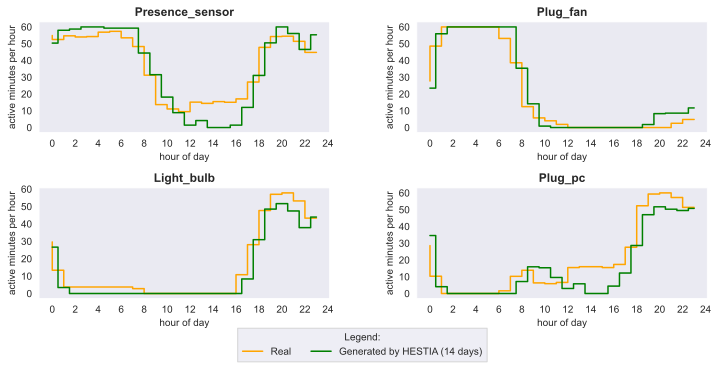

In [59]:
grafico_comportamento = grafico_linha(df1=real_transform2, df2=generated_transform2, df1_label='Real', df2_label='Generated by HESTIA (14 days)')
grafico_comportamento.savefig(PATH + "./minutes_per_hour2.pdf", bbox_inches='tight')

In [60]:
def converte_dados_para_teste_estatistico_por_hora(df1, df2):
    transform1 = df1.drop(['timeStamp'], axis=1).groupby(['date', 'hour']).sum()
    transform1['grupo'] = 'real'
    transform2 = df2.drop(['timeStamp'], axis=1).groupby(['date', 'hour']).sum()
    transform2['grupo'] = 'generated'
    
    return pd.concat([transform1, transform2], ignore_index=True)
    

In [61]:
teste_hora = converte_dados_para_teste_estatistico_por_hora(real_transform2, generated_transform2)
teste_hora.to_excel('teste_hora_agrupado.xlsx', engine='xlsxwriter')